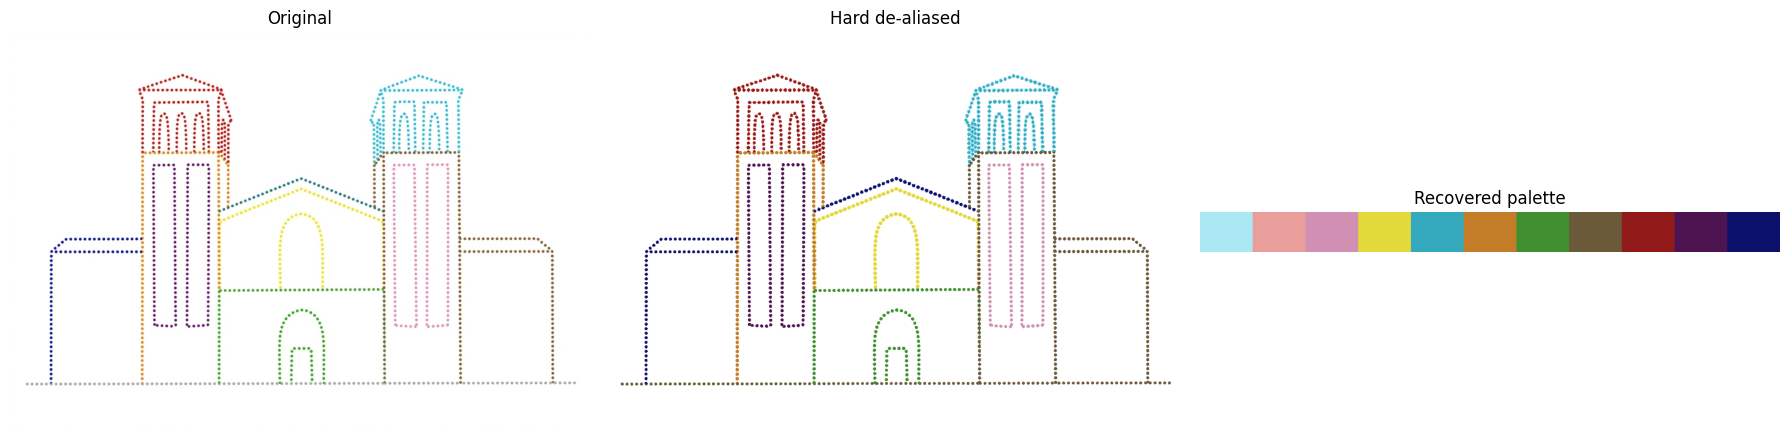

Saved: /home/owen/source/bloom/backend/services/image_dealiased.png
Palette:
(170, 233, 244)
(234, 158, 155)
(209, 144, 179)
(226, 218, 59)
(53, 170, 191)
(196, 125, 41)
(64, 144, 48)
(106, 90, 58)
(146, 26, 24)
(77, 20, 81)
(13, 17, 110)
Foreground pixels kept: 57,733


In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from scipy.ndimage import distance_transform_edt
from sklearn.cluster import KMeans

IMAGE_PATH = Path("image.png")
OUTPUT_PATH = Path("image_dealiased.png")
N_COLORS = 11
BACKGROUND_DELTA_THRESHOLD = 10.0
MIN_STRONG_DELTA = 35.0
MIN_ALPHA = 0.18
SEED_ALPHA = 0.45
RANDOM_STATE = 7


def load_rgb_image(path: Path) -> np.ndarray:
    return np.asarray(Image.open(path).convert("RGB"), dtype=np.uint8)


def merge_similar_colors(colors: np.ndarray, min_distance: float = 18.0) -> np.ndarray:
    kept: list[np.ndarray] = []
    for color in colors:
        if not kept:
            kept.append(color)
            continue

        distances = [np.linalg.norm(color.astype(np.float32) - other.astype(np.float32)) for other in kept]
        if min(distances) >= min_distance:
            kept.append(color)

    return np.asarray(kept, dtype=np.uint8)


def discover_palette(pixels: np.ndarray, n_colors: int) -> np.ndarray:
    flat_pixels = pixels.reshape(-1, 3).astype(np.float32)
    delta_from_white = 255.0 - flat_pixels
    delta_strength = np.linalg.norm(delta_from_white, axis=1)

    strong_pixels = delta_from_white[delta_strength > MIN_STRONG_DELTA]
    if len(strong_pixels) < n_colors:
        raise ValueError("Not enough colored pixels to infer the palette.")

    normalized = strong_pixels / np.linalg.norm(strong_pixels, axis=1, keepdims=True)
    model = KMeans(n_clusters=n_colors, n_init=20, random_state=RANDOM_STATE)
    labels = model.fit_predict(normalized)

    palette = []
    for cluster_index in range(n_colors):
        cluster = strong_pixels[labels == cluster_index]
        representative_delta = np.percentile(cluster, 98, axis=0)
        representative_color = np.clip(255.0 - representative_delta, 0, 255).round().astype(np.uint8)
        palette.append(representative_color)

    palette = np.asarray(palette, dtype=np.uint8)
    palette = palette[np.argsort(np.sum(255 - palette, axis=1))]
    return merge_similar_colors(palette)


def classify_pixels(pixels: np.ndarray, palette: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    flat_pixels = pixels.reshape(-1, 3).astype(np.float32)
    delta_from_white = 255.0 - flat_pixels
    delta_strength = np.linalg.norm(delta_from_white, axis=1)

    palette_delta = 255.0 - palette.astype(np.float32)
    denom = np.sum(palette_delta * palette_delta, axis=1)

    alpha = (delta_from_white @ palette_delta.T) / denom
    alpha = np.clip(alpha, 0.0, 1.0)

    reconstructions = 255.0 - alpha[:, :, None] * palette_delta[None, :, :]
    reconstruction_error = np.linalg.norm(flat_pixels[:, None, :] - reconstructions, axis=2)
    best_match = reconstruction_error.argmin(axis=1)
    best_alpha = alpha[np.arange(len(flat_pixels)), best_match]

    foreground_mask = (delta_strength >= BACKGROUND_DELTA_THRESHOLD) & (best_alpha >= MIN_ALPHA)
    return best_match, best_alpha, foreground_mask


def hard_dealias(pixels: np.ndarray, palette: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    height, width = pixels.shape[:2]
    best_match, best_alpha, foreground_mask = classify_pixels(pixels, palette)

    seed_mask = foreground_mask & (best_alpha >= SEED_ALPHA)
    labels = np.full(height * width, -1, dtype=np.int32)
    labels[seed_mask] = best_match[seed_mask]

    foreground_2d = foreground_mask.reshape(height, width)
    seed_2d = seed_mask.reshape(height, width)
    labels_2d = labels.reshape(height, width)

    if seed_2d.any():
        _, nearest_seed_indices = distance_transform_edt(~seed_2d, return_indices=True)
        nearest_rows, nearest_cols = nearest_seed_indices
        propagated_labels = labels_2d[nearest_rows, nearest_cols]
        final_labels = np.where(foreground_2d, propagated_labels, -1)
    else:
        final_labels = np.where(foreground_2d, best_match.reshape(height, width), -1)

    result = np.full((height, width, 3), 255, dtype=np.uint8)
    colored_mask = final_labels >= 0
    result[colored_mask] = palette[final_labels[colored_mask]]

    return result, best_alpha.reshape(height, width)


def build_palette_strip(colors: np.ndarray, swatch_width: int = 80, swatch_height: int = 60) -> np.ndarray:
    strip = np.zeros((swatch_height, swatch_width * len(colors), 3), dtype=np.uint8)
    for index, color in enumerate(colors):
        strip[:, index * swatch_width : (index + 1) * swatch_width] = color
    return strip


pixels = load_rgb_image(IMAGE_PATH)
palette = discover_palette(pixels, n_colors=N_COLORS)
dealiased, alpha = hard_dealias(pixels, palette)

Image.fromarray(dealiased).save(OUTPUT_PATH)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(pixels)
axes[0].set_title("Original")
axes[1].imshow(dealiased)
axes[1].set_title("Hard de-aliased")
axes[2].imshow(build_palette_strip(palette))
axes[2].set_title("Recovered palette")
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()

print(f"Saved: {OUTPUT_PATH.resolve()}")
print("Palette:")
for color in palette:
    print(tuple(int(channel) for channel in color))
print(f"Foreground pixels kept: {(alpha >= MIN_ALPHA).sum():,}")